# Data Plot Examples

See https://www.data-to-viz.com/ for more help. Plotly might be useful for interactions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('./data/txreg_scrambled.csv')

Single Variable: Numeric

Text(0.5, 1.0, 'Number of patients with this variable: 14950')

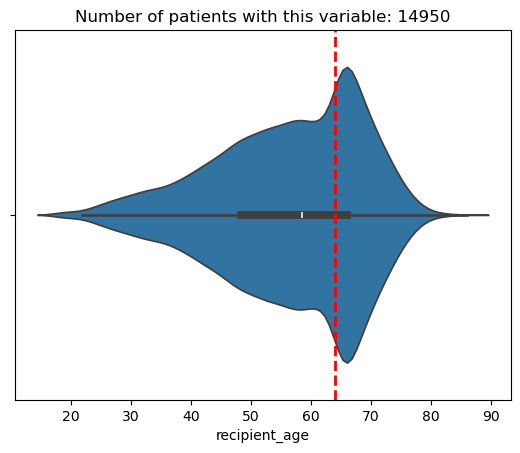

In [36]:
col = data["recipient_age"]
enteredvalue = col.dropna().sample(1).iloc[0]

notmissing = (~col.isnull()).sum()
ax = sns.violinplot(x=col)
ax.axvline(enteredvalue, color='red', linestyle='--', linewidth=2)
ax.set_title(f"Number of patients with this variable: {notmissing}")

Single Variable: Category (Other is sometimes a real category)

Text(0.5, 1.0, 'Number of patients with this variable: 14950')

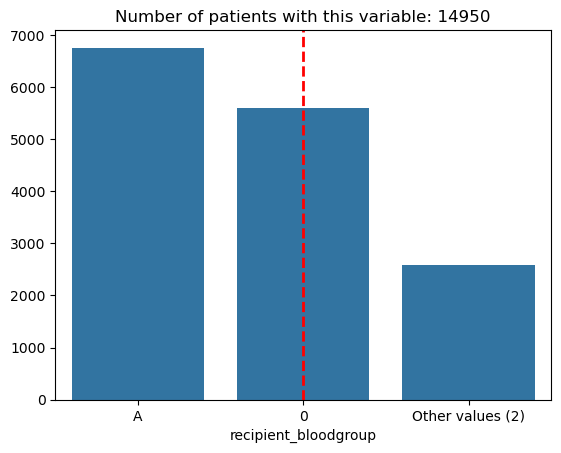

In [51]:
col = data["recipient_bloodgroup"]
enteredvalue = col.dropna().sample(1).iloc[0]
toshow = 2 # as an example

notmissing = (~col.isnull()).sum()
valcount = col.value_counts(dropna=False).sort_values(ascending=False)
topcounts = valcount.head(toshow)
othercounts = valcount.iloc[toshow:]
topcounts[f"Other values ({len(othercounts)})"] = othercounts.sum()

if enteredvalue in othercounts.index:
    enteredvalue = topcounts.index[-1]

topcounts = topcounts.sort_values(ascending=False)

ax = sns.barplot(x=topcounts.index, y=topcounts.values)
ax.axvline(enteredvalue, color='red', linestyle='--', linewidth=2)
ax.set_title(f"Number of patients with this variable: {notmissing}")

Single Variable: Multinominal

'Corticosteroids;;MMF-Cellcept;;Tacrolimus (FK-506)'

Text(0.5, 1.0, 'Number of values used by patients with this variable')

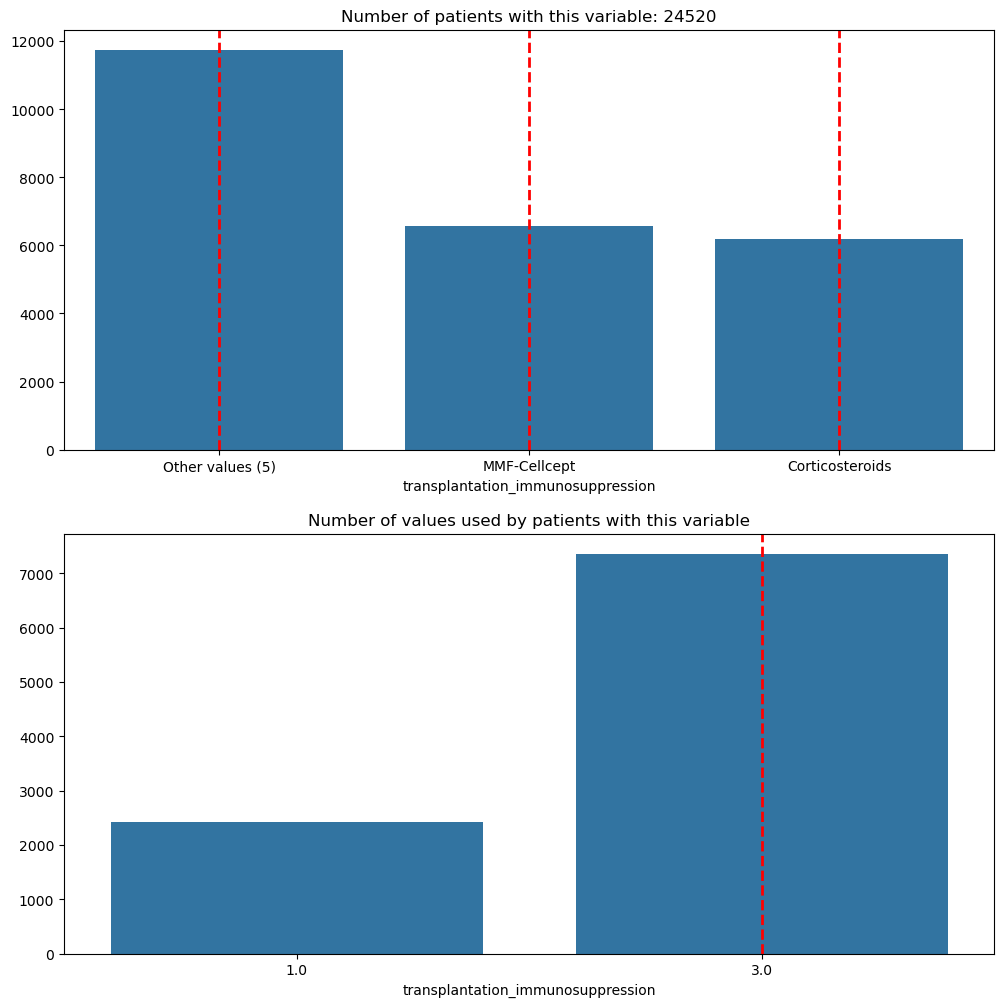

In [73]:
col = data["transplantation_immunosuppression"]
enteredvalue = col.dropna().sample(1).iloc[0]
display(enteredvalue)
toshow = 3 # as an example


#
# Occuring values
#

exploded = col.str.split(';;').explode().str.strip()

notmissing = (~exploded.isnull()).sum()
valcount = exploded.value_counts(dropna=False).sort_values(ascending=False)
topcounts = valcount.head(toshow)
othercounts = valcount.iloc[toshow:]
topcounts[f"Other values ({len(othercounts)})"] = othercounts.sum()

entredvalue = enteredvalue.split(';;')
entredvalue = [topcounts.index[-1] if x in othercounts.index else x for x in entredvalue]

topcounts = topcounts.sort_values(ascending=False)


#
# Number of values
#

valcount = col.str.count(";;").add(1).value_counts().sort_values(ascending=False)
enteredvalue_len = len(entredvalue)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

ax = sns.barplot(x=topcounts.index, y=topcounts.values, ax=ax1)
for value in entredvalue:
    ax.axvline(value, color='red', linestyle='--', linewidth=2)
ax.set_title(f"Number of patients with this variable: {notmissing}")

ax = sns.barplot(x=valcount.index, y=valcount.values, ax=ax2)
# str(float) is necessary to avoid issues with matplotlib, using the number as a index
ax.axvline(str(float(enteredvalue_len)), color='red', linestyle='--', linewidth=2)
ax.set_title("Number of values used by patients with this variable")

Numeric vs Numeric

Hexagons are better than squares for various reasons.

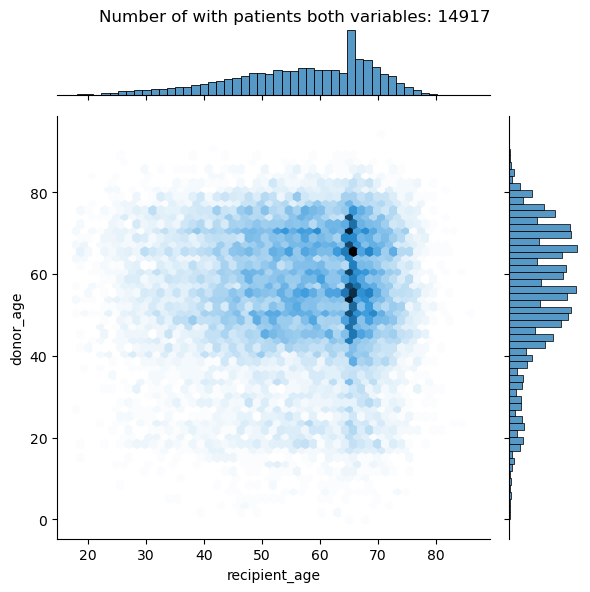

In [ ]:
colA = data["recipient_age"]
colB = data["donor_age"]

available = (~colA.isnull()) & (~colB.isnull())
available = available.sum()

# todo: include the red lines for the entered data

jg = sns.jointplot(x=colA, y=colB, kind="hex")
jg.figure.suptitle(f"Number of with patients both variables: {available}")
jg.figure.tight_layout()
jg.figure.subplots_adjust(top=0.95)

Categoric vs Categoric

Text(0.5, 1.0, 'Number of patients with both variables: 14930')

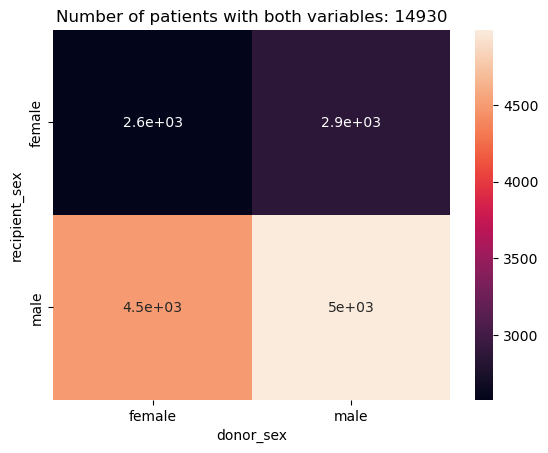

In [ ]:
colA = data["recipient_sex"]
colB = data["donor_sex"]

# TODO here, also summarise for features with many values

countmat = pd.crosstab(colA, colB, dropna=True)
available = (~colA.isnull()) & (~colB.isnull())
available = available.sum()

ax = sns.heatmap(countmat, annot=True)
ax.set_title(f"Number of patients with both variables: {available}")

Categoric vs Numeric

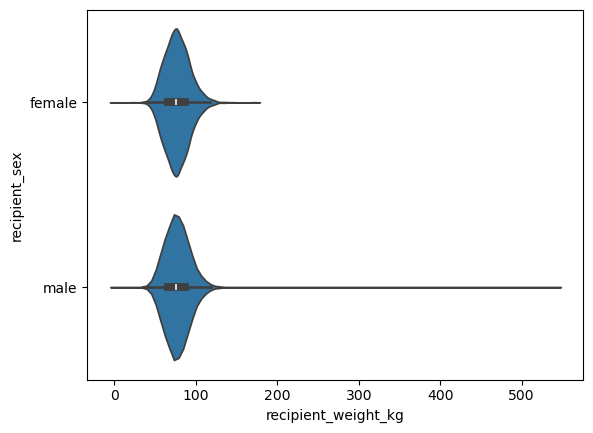

In [ ]:
numcol = data["recipient_weight_kg"]
catcol = data["recipient_sex"]

# TODO here, also summarise for features with many values
# TODO: outliers are a problem here, tip: limit to 2.5*IQR

available = (~colA.isnull()) & (~colB.isnull())
available = available.sum()

ax = sns.violinplot(x=numcol, y=catcol)


Single Variable: Multinominal, Kombination der beiden Typen (Länge ist numerisch, vorkommenden Werte kategorisch)